## 1. Data Loading and Initial Inspection

This section imports the required libraries, loads the UCI Credit Card dataset, and performs an initial inspection to verify column types, data shapes, and the presence of missing values.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv(r"C:\Users\zeyne\Desktop\UCI_Credit_Card.csv\UCI_Credit_Card.csv")

print("--- General Informations ---")
print(df.info())

print("\n--- Missing Value Control ---")
print(df.isnull().sum())




--- General Informations ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BI

## 2. Duplicate Record Check

Checks for the total number of duplicate rows in the dataset to ensure data integrity prior to analysis.

In [2]:
df.duplicated().sum()

np.int64(0)

## 3. Categorical Variable Anomaly Detection

Validates the categorical columns (`SEX`, `EDUCATION`, `MARRIAGE`, `PAY_n`) against the expected value ranges defined in the UCI dataset documentation. Any undocumented or out-of-range values are flagged as anomalies and reported with their frequency and percentage.

In [ ]:
# --- REFERENCE INFORMATION (Expected Values per Documentation) ---
expected_values = {
    'SEX': [1, 2],                 # 1=Male, 2=Female
    'EDUCATION': [1, 2, 3, 4],     # 1=Graduate School, 2=University, 3=High School, 4=Other
    'MARRIAGE': [1, 2, 3],         # 1=Married, 2=Single, 3=Other
}

print("--- ANOMALY DETECTION REPORT ---\n")

for col, expected in expected_values.items():
    actual = df[col].unique()
    # Identify values that are not present in the expected list
    anomalies = [val for val in actual if val not in expected]
    
    if anomalies:
        print(f"{col} Column Has Issues!")
        print(f"  - Expected Values: {expected}")
        print(f"  - Detected Anomalies: {anomalies}")
        for anomaly in anomalies:
            count = len(df[df[col] == anomaly])
            percent = (count / len(df)) * 100
            print(f"    > Value '{anomaly}' appears {count} times ({percent:.2f}%)")
    else:
        print(f"{col} Column is Clean.")
    print("-" * 30)


# Documentation states: -1=Paid on time, 1=Delay, 2=Delay...
# However, values -2 and 0 are also present in the data and must be inspected.
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
print("\n--- PAYMENT STATUS (PAY_n) UNDOCUMENTED VALUES ---")
for col in pay_cols:
    print(f"{col} — all unique values: {sorted(df[col].unique())}")

--- ANOMALY DETECTION REPORT ---

SEX Column is Clean.
------------------------------
EDUCATION Column Has Issues!
  - Expected Values: [1, 2, 3, 4]
  - Detected Anomalies: [np.int64(5), np.int64(6), np.int64(0)]
    > Value '5' appears 280 times (0.93%)
    > Value '6' appears 51 times (0.17%)
    > Value '0' appears 14 times (0.05%)
------------------------------
MARRIAGE Column Has Issues!
  - Expected Values: [1, 2, 3]
  - Detected Anomalies: [np.int64(0)]
    > Value '0' appears 54 times (0.18%)
------------------------------

--- PAYMENT STATUS (PAY_n) UNDOCUMENTED VALUES ---
PAY_0 — all unique values: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2 — all unique values: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3 — all unique values: [np.int64(-2), np.int64(-1), np.int64(

## 4. Visualization of Categorical Anomalies

Visualizes the distribution of the `EDUCATION` and `MARRIAGE` columns using count plots. Anomalous categories (values outside the documented range) are visually identifiable as unexpected bars.

C:\Users\zeyne\AppData\Local\Temp\ipykernel_31932\2201556233.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='EDUCATION', data=df, ax=axes[0], palette="muted")
C:\Users\zeyne\AppData\Local\Temp\ipykernel_31932\2201556233.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='MARRIAGE', data=df, ax=axes[1], palette="pastel")


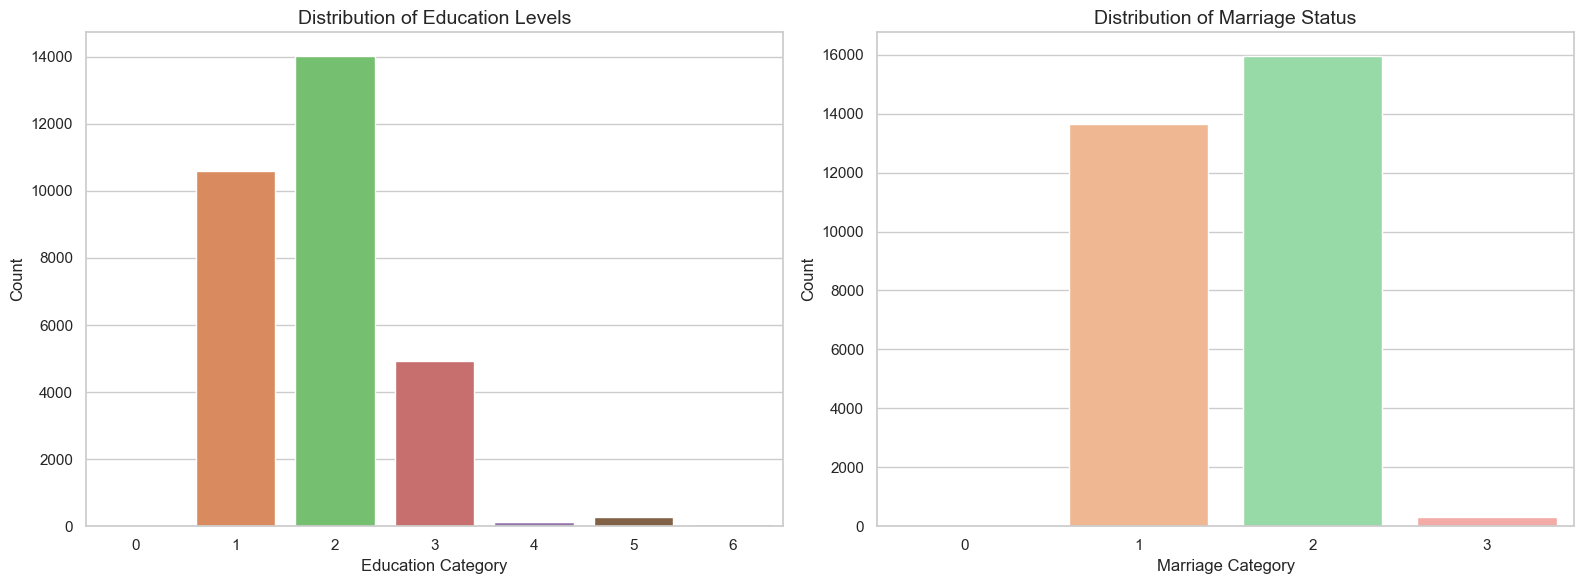

In [4]:
# Set global plot style
sns.set_theme(style="whitegrid")

# Create a 1x2 grid for demographic features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Education distribution and anomalies
# Expected values: 1, 2, 3, 4. Values 0, 5, 6 are identified as anomalies.
sns.countplot(x='EDUCATION', data=df, ax=axes[0], palette="muted")
axes[0].set_title('Distribution of Education Levels', fontsize=14)
axes[0].set_xlabel('Education Category')
axes[0].set_ylabel('Count')

# 2. Marriage distribution and anomalies
# Expected values: 1, 2, 3. Value 0 is identified as an anomaly.
sns.countplot(x='MARRIAGE', data=df, ax=axes[1], palette="pastel")
axes[1].set_title('Distribution of Marriage Status', fontsize=14)
axes[1].set_xlabel('Marriage Category')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 5. Monthly Payment Status Distribution (PAY_n)

Generates a 2×3 grid of count plots for the six monthly repayment status columns (`PAY_0` through `PAY_6`). The distribution reveals the presence of undocumented values (`-2` and `0`) alongside the officially defined delay categories.

C:\Users\zeyne\AppData\Local\Temp\ipykernel_31932\1482105546.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[row, column], palette="viridis")
C:\Users\zeyne\AppData\Local\Temp\ipykernel_31932\1482105546.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[row, column], palette="viridis")
C:\Users\zeyne\AppData\Local\Temp\ipykernel_31932\1482105546.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[row, column], palette="viridis")
C:\Users\zeyne\AppData\Local

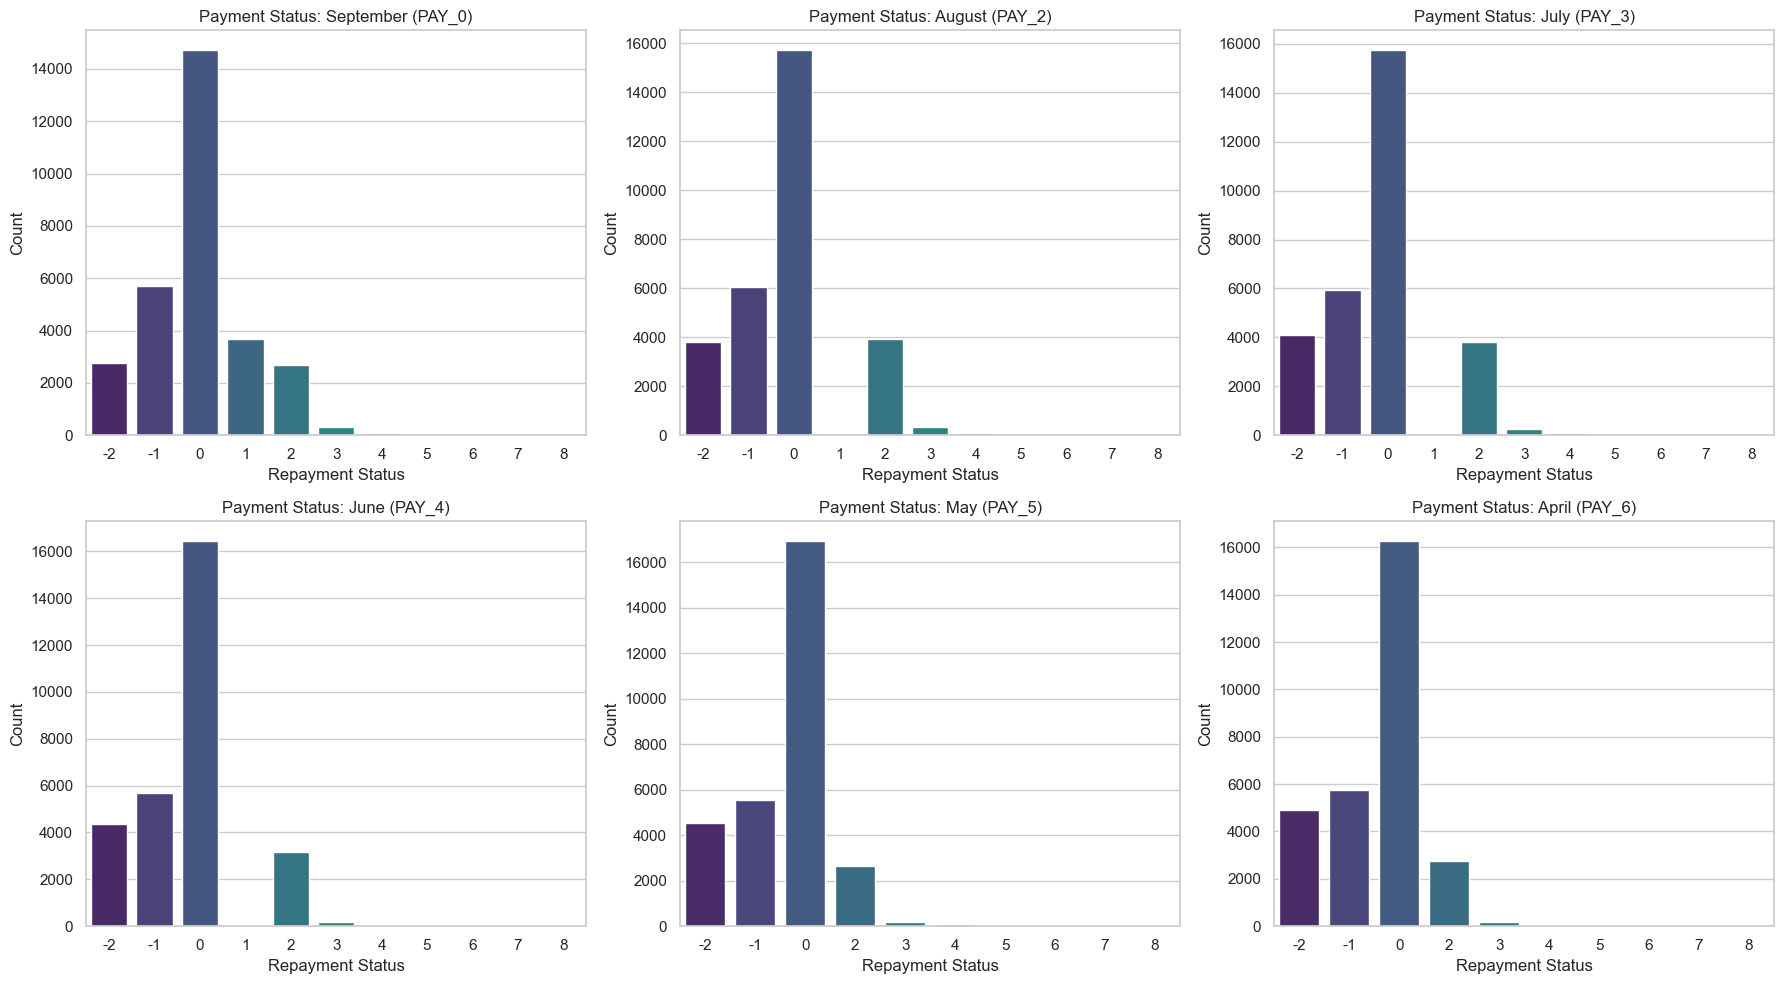

In [5]:
# Create a 2x3 grid for the 6-month payment status history
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Define column names and corresponding month labels
pay_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
titles = ['September', 'August', 'July', 'June', 'May', 'April']

# Iterate through payment columns to generate subplots
for i, col in enumerate(pay_columns):
    row = i // 3
    column = i % 3
    
    # Analyze the distribution of delay status including -2 and 0
    sns.countplot(x=col, data=df, ax=axes[row, column], palette="viridis")
    axes[row, column].set_title(f'Payment Status: {titles[i]} ({col})')
    axes[row, column].set_xlabel('Repayment Status')
    axes[row, column].set_ylabel('Count')

# Finalize layout to prevent overlapping
plt.tight_layout()
plt.show()

## 6. Categorical Data Cleaning

Resolves the detected anomalies by remapping undocumented values to the closest valid category. Specifically, `EDUCATION` values `{0, 5, 6}` and `MARRIAGE` value `0` are reassigned to the `Others` category (code 4 and 3, respectively), in line with standard UCI preprocessing practice.

In [6]:
# --- EDUCATION Column Cleaning ---
# Mapping 0, 5, and 6 to category 4 (Others)
# According to UCI documentation, these represent undocumented or unknown categories.
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)

# --- MARRIAGE Column Cleaning ---
# Mapping 0 to category 3 (Others)
# Since 0 is undocumented, merging it with the existing 'Others' group is the standard approach.
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

# Verify the results
print("Final unique values in EDUCATION:", sorted(df['EDUCATION'].unique()))
print("Final unique values in MARRIAGE:", sorted(df['MARRIAGE'].unique()))

Final unique values in EDUCATION: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Final unique values in MARRIAGE: [np.int64(1), np.int64(2), np.int64(3)]


## 7. Descriptive Statistics of Numerical Features

Computes summary statistics (count, mean, standard deviation, min, quartiles, max) for all numerical columns, providing an overview of the scale and spread of financial variables such as credit limits, bill amounts, and payment amounts.

In [7]:
numerical_cols = [
    "LIMIT_BAL","AGE",
    "BILL_AMT1","BILL_AMT2","BILL_AMT3",
    "BILL_AMT4","BILL_AMT5","BILL_AMT6",
    "PAY_AMT1","PAY_AMT2","PAY_AMT3",
    "PAY_AMT4","PAY_AMT5","PAY_AMT6"
]

df[numerical_cols].describe()

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,9.217904,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,21.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,34.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,41.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,79.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


## 8. Outlier Detection via Box Plots

Renders box plots for a representative subset of numerical columns (`LIMIT_BAL`, `AGE`, `BILL_AMT1`, `PAY_AMT1`) to visually identify the presence and magnitude of extreme outliers.

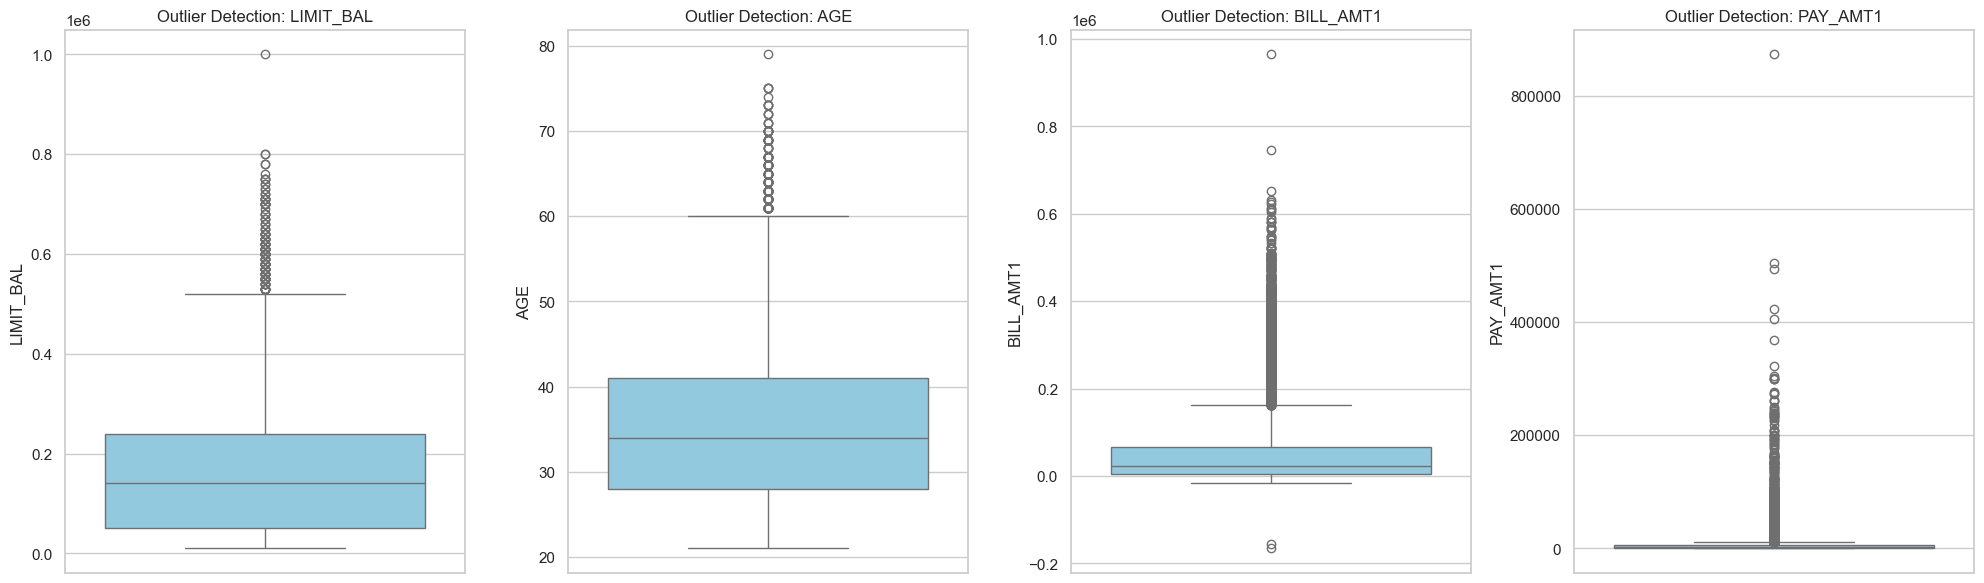

In [8]:
# Define numerical columns for analysis
num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']

# Create subplots to observe distribution and outliers
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Outlier Detection: {col}')

plt.tight_layout()
plt.show()

## 9. Distribution Analysis of Numerical Features

Examines the frequency and density distributions of all major numerical columns in three grouped panels:

1. **LIMIT_BAL & AGE** — general demographic and financial capacity features.
2. **BILL_AMT1–6** — monthly statement amounts with a reference line at zero to highlight negative (credit) balances.
3. **PAY_AMT1–6** — monthly payment amounts visualized on a log scale due to extreme right-skewness.

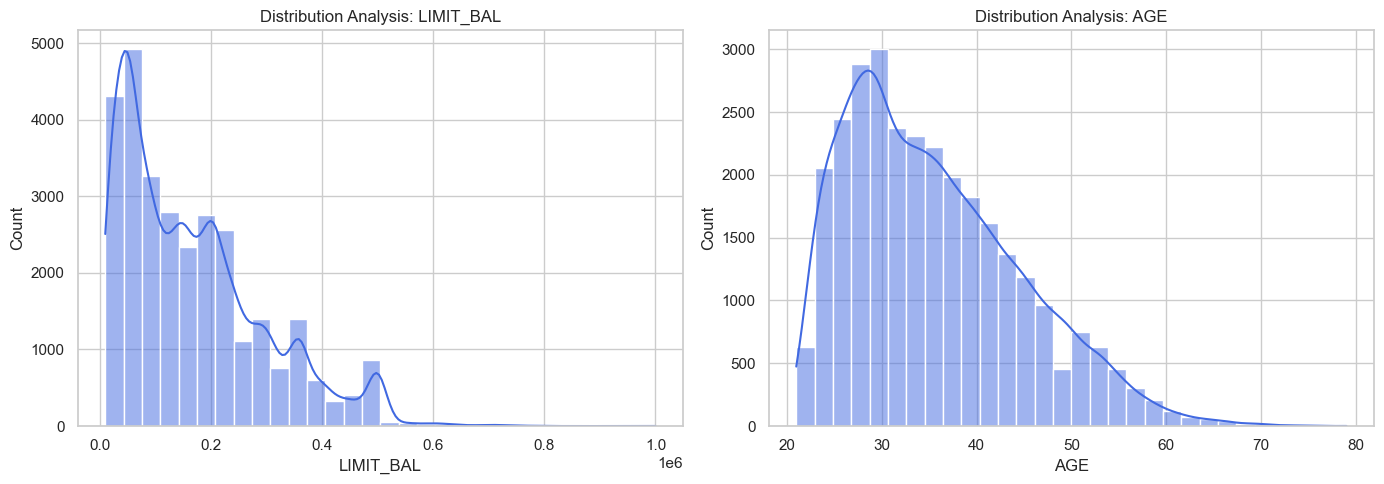

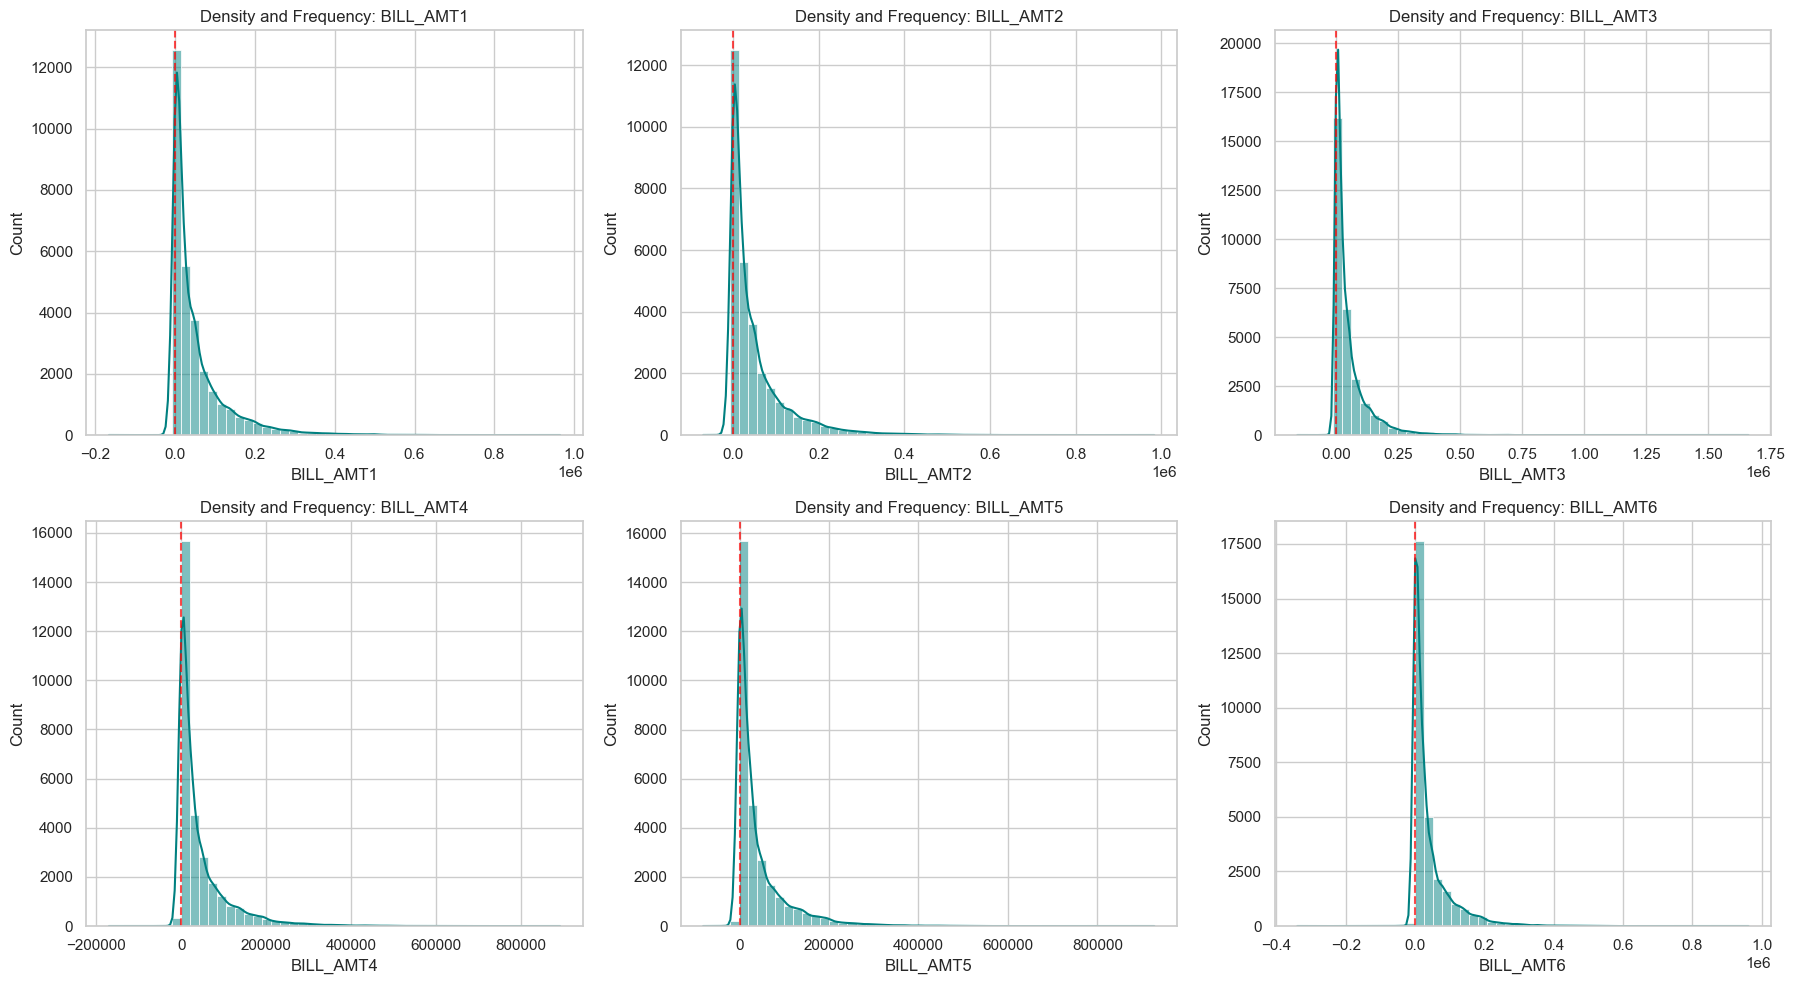

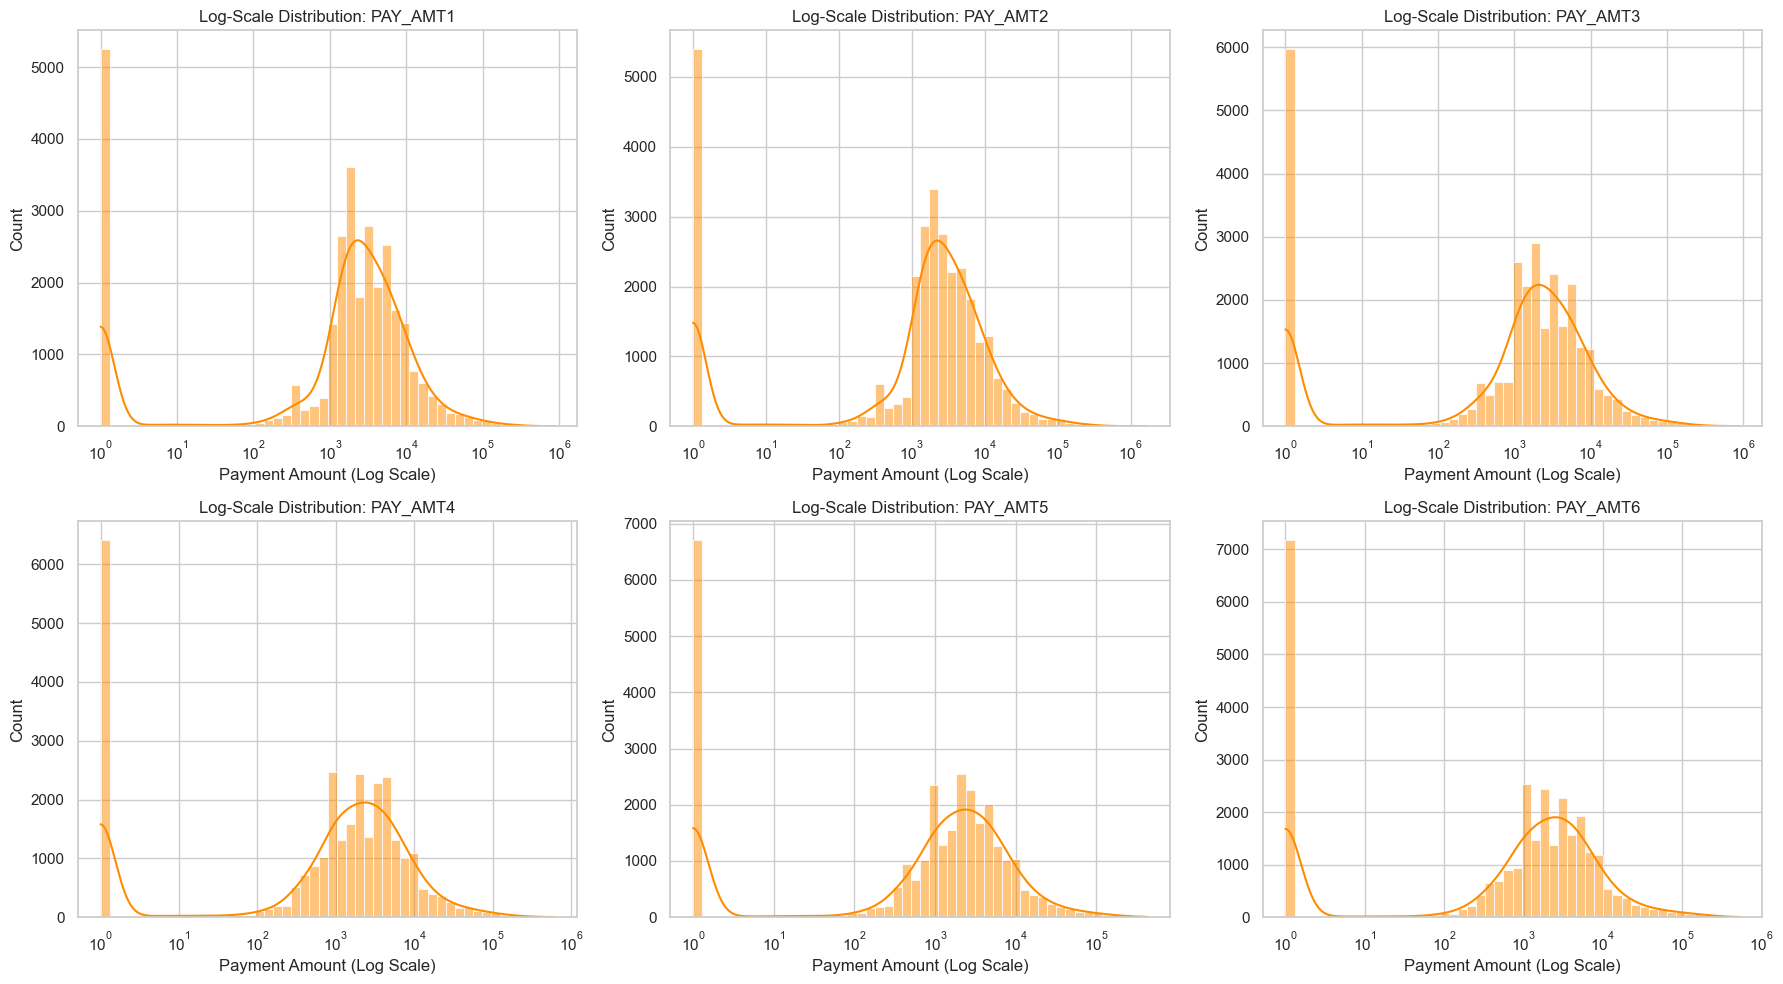

In [9]:
# Define numerical groups for structured visualization
limit_age = ['LIMIT_BAL', 'AGE']
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Set global aesthetics
sns.set_theme(style="whitegrid")

# --- 1. Analysis of Limit Balance and Age ---
plt.figure(figsize=(14, 5))
for i, col in enumerate(limit_age, 1):
    plt.subplot(1, 2, i)
    # Plot histogram with Kernel Density Estimate (KDE)
    sns.histplot(df[col], kde=True, bins=30, color='royalblue')
    plt.title(f'Distribution Analysis: {col}')
plt.tight_layout()
plt.show()

# --- 2. Analysis of Bill Amounts (BILL_AMT) ---
# Visualizing the distribution of monthly bill statements
plt.figure(figsize=(18, 10))
for i, col in enumerate(bill_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=50, color='teal')
    # Add a reference line at 0 to distinguish negative balances (credits)
    plt.axvline(0, color='red', linestyle='--', alpha=0.7)
    plt.title(f'Density and Frequency: {col}')
plt.tight_layout()
plt.show()

# --- 3. Analysis of Payment Amounts (PAY_AMT) ---
# Using log scale for PAY_AMT due to extreme right-skewness and high outliers
plt.figure(figsize=(18, 10))
for i, col in enumerate(pay_cols, 1):
    plt.subplot(2, 3, i)
    # Apply log transformation (x+1) to handle 0 values in payment amounts
    sns.histplot(df[col] + 1, kde=True, bins=50, color='darkorange', log_scale=True)
    plt.title(f'Log-Scale Distribution: {col}')
    plt.xlabel('Payment Amount (Log Scale)')
plt.tight_layout()
plt.show()

## 10. Outlier Treatment — LIMIT_BAL (99th Percentile Capping)

Applies a winsorization strategy to `LIMIT_BAL` by capping values above the 99th percentile threshold. This mitigates the influence of extreme credit limits on model training without discarding any records.

In [10]:
# Capping LIMIT_BAL at the 99th percentile to handle extreme outliers
limit_threshold = df['LIMIT_BAL'].quantile(0.99)

# Apply capping
df.loc[df['LIMIT_BAL'] > limit_threshold, 'LIMIT_BAL'] = limit_threshold

# Log the decision for report documentation
print(f"LIMIT_BAL capped at: {limit_threshold}")

LIMIT_BAL capped at: 500000.0


## 11. Outlier Treatment — Payment Amounts (99th Percentile Capping)

Applies the same 99th percentile capping to all six `PAY_AMT` columns to suppress extreme payment values. Negative values in `BILL_AMT` columns are intentionally preserved, as they constitute approximately 2% of the data and represent valid credit (overpayment) events.

In [11]:
# Capping extreme outliers at the 99th percentile for payment columns
pay_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

for col in pay_cols:
    # Identify the 99th percentile threshold
    upper_limit = df[col].quantile(0.99)
    # Cap values above the threshold
    df.loc[df[col] > upper_limit, col] = upper_limit

# Keep negative values in BILL_AMT as they represent 2% of the data and carry financial meaning

## 12. Target Variable Analysis — Class Distribution

Renames the target column to `Is_Default` for readability, then visualizes and quantifies the class imbalance. The annotated count plot displays the proportion of defaulting vs. non-defaulting clients, establishing the baseline for imbalance-aware modeling decisions.

C:\Users\zeyne\AppData\Local\Temp\ipykernel_31932\1694857782.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Is_Default', data=df, palette='viridis')


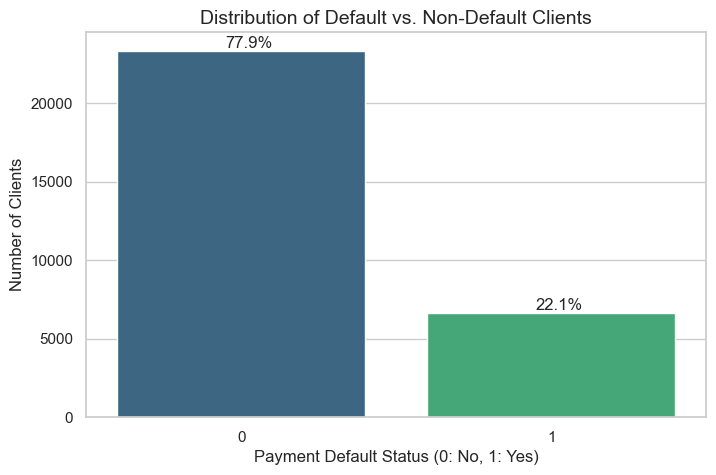

--- Class Distribution ---
Is_Default
0    23364
1     6636
Name: count, dtype: int64

--- Class Ratios ---
Is_Default
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [12]:
# Shorten the target variable name for easier handling during analysis
df.rename(columns={'default.payment.next.month': 'Is_Default'}, inplace=True)

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Target Variable Distribution (Countplot)
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Is_Default', data=df, palette='viridis')

# Annotating the bars with percentages
total = len(df['Is_Default'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height()
    ax.annotate(percentage, (x, y), size=12, va='bottom')

plt.title('Distribution of Default vs. Non-Default Clients', fontsize=14)
plt.xlabel('Payment Default Status (0: No, 1: Yes)')
plt.ylabel('Number of Clients')
plt.show()

# 2. Precise Value Counts
print("--- Class Distribution ---")
print(df['Is_Default'].value_counts())
print("\n--- Class Ratios ---")
print(df['Is_Default'].value_counts(normalize=True))

## 13. Categorical Features vs. Default Status

Explores the relationship between demographic categorical features (`SEX`, `EDUCATION`, `MARRIAGE`) and the target variable `Is_Default` using grouped count plots. This provides an initial indication of whether any demographic group exhibits a statistically notable default rate.

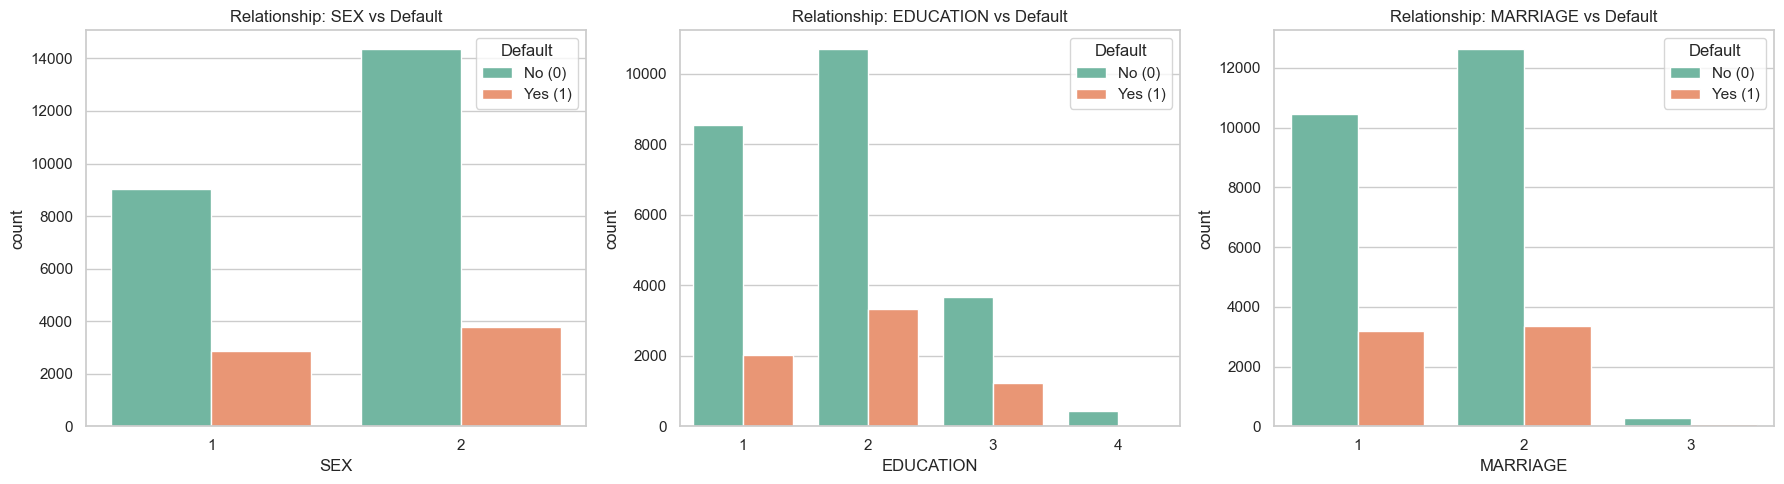

In [13]:
df.rename(columns={'default.payment.next.month': 'Is_Default'}, inplace=True)
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

# Analyzing categorical relationships
cat_features = ['SEX', 'EDUCATION', 'MARRIAGE']

plt.figure(figsize=(18, 5))

for i, col in enumerate(cat_features, 1):
    plt.subplot(1, 3, i)
    # Using 'hue' to see the target distribution within categories
    sns.countplot(x=col, hue='Is_Default', data=df, palette='Set2')
    plt.title(f'Relationship: {col} vs Default')
    plt.legend(title='Default', labels=['No (0)', 'Yes (1)'])

plt.tight_layout()
plt.show()

## 14. Feature Correlation with Default Status

Computes and visualizes pairwise correlations between all features and the target variable `Is_Default`. Additionally, box and KDE plots compare the distributions of `LIMIT_BAL` and `AGE` across defaulting and non-defaulting client groups to assess their discriminative power.

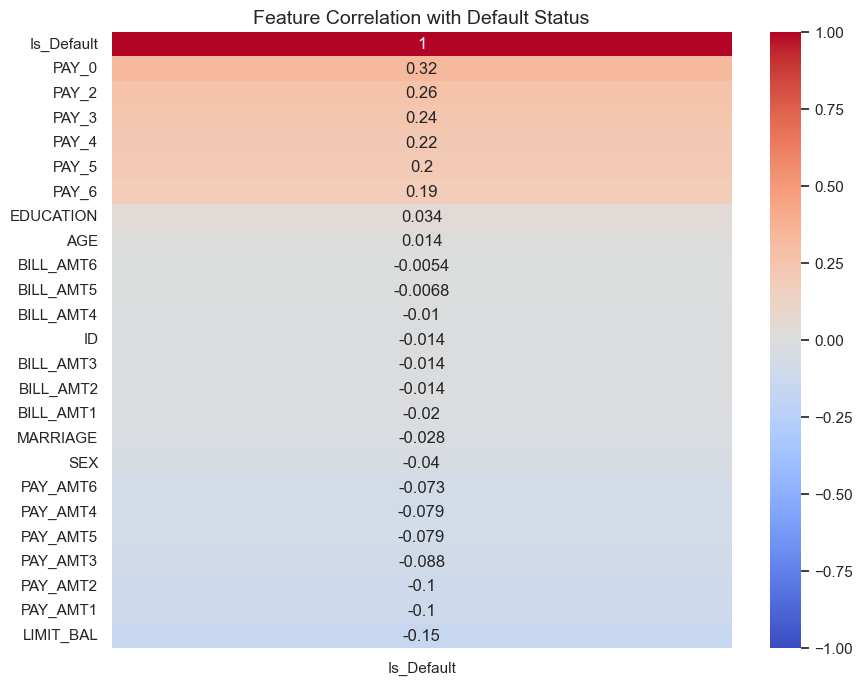

C:\Users\zeyne\AppData\Local\Temp\ipykernel_31932\3858459588.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is_Default', y='LIMIT_BAL', data=df, palette='Set2')


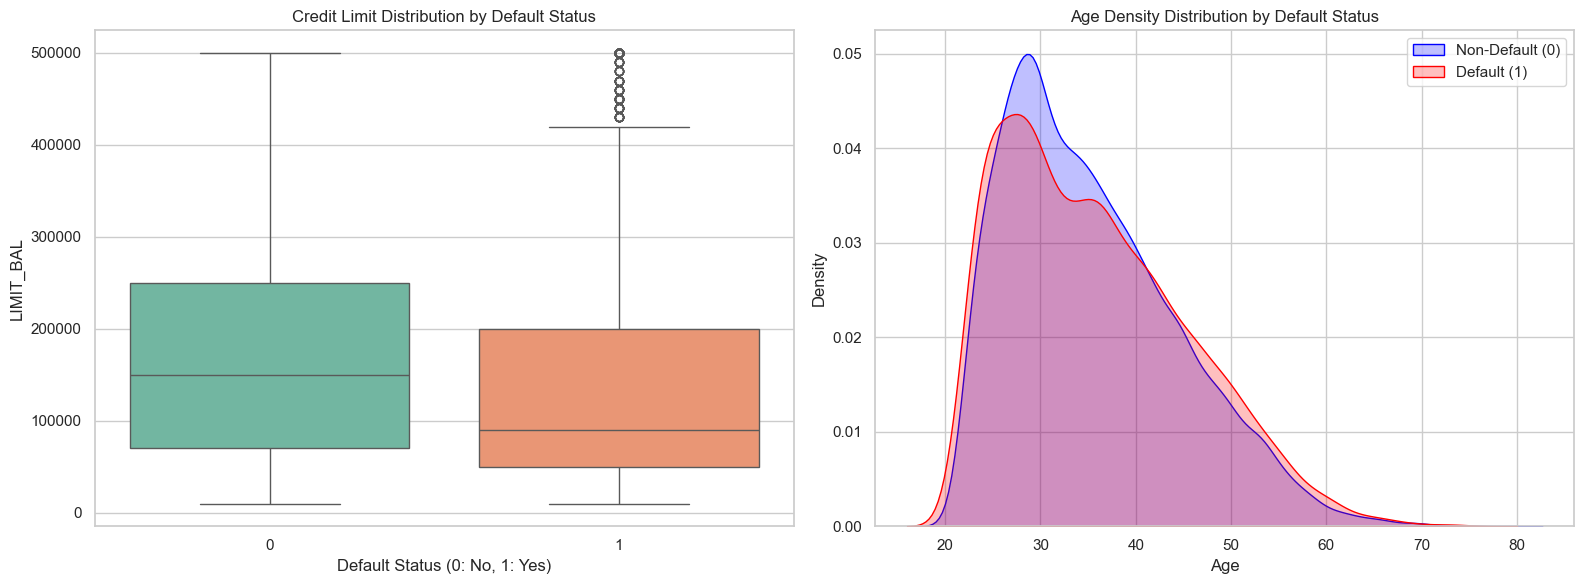

In [14]:
# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
# Focusing on the correlation with the target variable
sns.heatmap(correlation_matrix[['Is_Default']].sort_values(by='Is_Default', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation with Default Status', fontsize=14)
plt.show()

# 2. Comparative Analysis: LIMIT_BAL and AGE
plt.figure(figsize=(16, 6))

# Plot 1: Credit Limit vs Default
plt.subplot(1, 2, 1)
sns.boxplot(x='Is_Default', y='LIMIT_BAL', data=df, palette='Set2')
plt.title('Credit Limit Distribution by Default Status', fontsize=12)
plt.xlabel('Default Status (0: No, 1: Yes)')

# Plot 2: Age Distribution vs Default
plt.subplot(1, 2, 2)
sns.kdeplot(df[df['Is_Default'] == 0]['AGE'], label='Non-Default (0)', fill=True, color='blue')
sns.kdeplot(df[df['Is_Default'] == 1]['AGE'], label='Default (1)', fill=True, color='red')
plt.title('Age Density Distribution by Default Status', fontsize=12)
plt.xlabel('Age')
plt.legend()

plt.tight_layout()
plt.show()

## 15. Inter-Correlation Analysis — Billing Amounts (BILL_AMT1–6)

Computes and visualizes the correlation matrix among the six monthly billing amount columns. High inter-correlation suggests potential multicollinearity and may justify feature aggregation or dimensionality reduction in subsequent modeling steps.

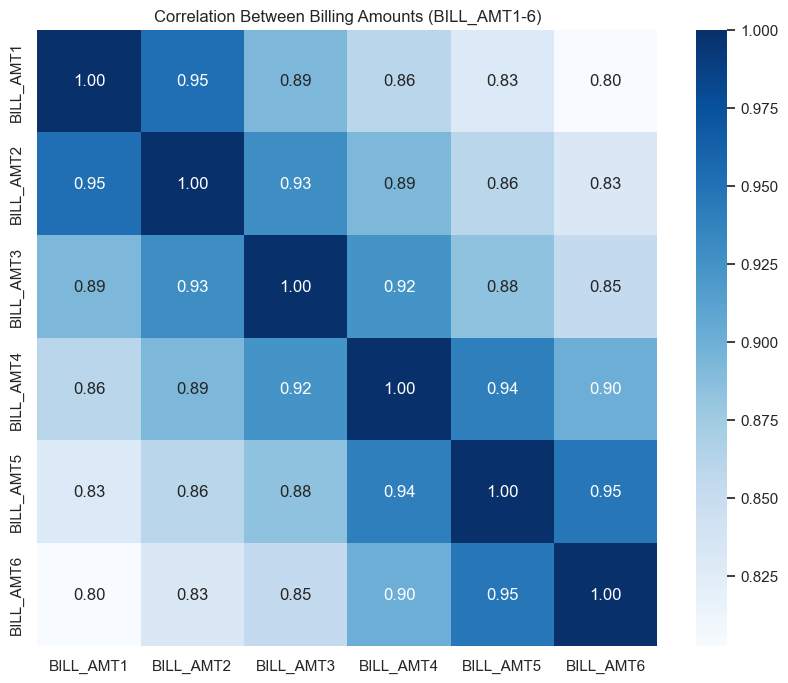

In [15]:
# 1. Detailed Correlation Heatmap for BILL_AMT Columns
# High correlation among BILL_AMT1-6 indicates potential multicollinearity.
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
bill_corr = df[bill_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(bill_corr, annot=True, cmap='Blues', fmt=".2f")
plt.title('Correlation Between Billing Amounts (BILL_AMT1-6)')
plt.show()

## 16. Inter-Correlation Analysis — Payment Amounts (PAY_AMT1–6)

Generates a correlation heatmap for the six monthly payment amount columns to assess their linear relationships. Lower inter-correlation here (compared to `BILL_AMT`) suggests that payment behavior varies more independently across months.

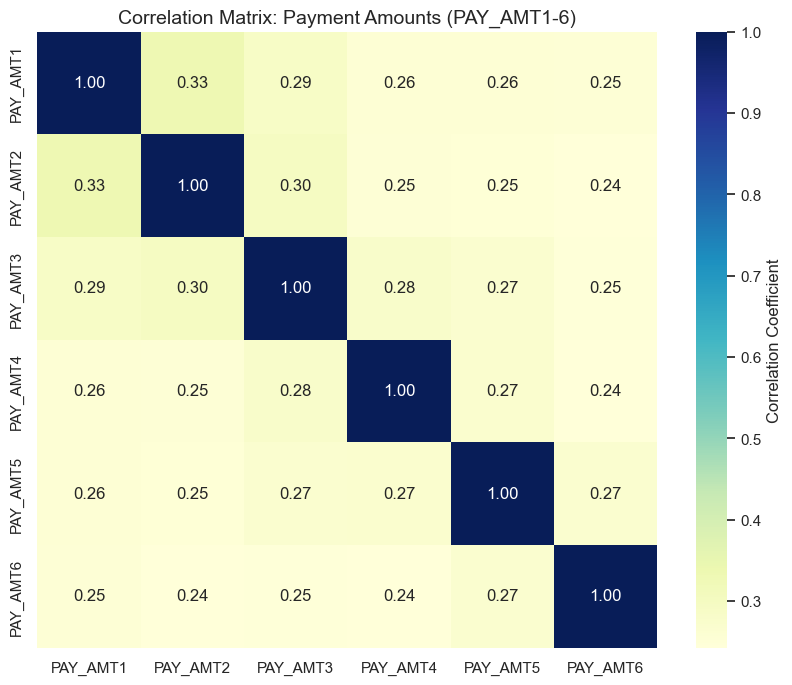

In [16]:
# Selecting payment columns
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
pay_corr = df[pay_amt_cols].corr()

# Plotting the heatmap for PAY_AMT
plt.figure(figsize=(10, 8))
sns.heatmap(pay_corr, annot=True, cmap='YlGnBu', fmt=".2f", cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix: Payment Amounts (PAY_AMT1-6)', fontsize=14)
plt.show()

## 17. Baseline Model Training and Evaluation

Trains three baseline classifiers — Decision Tree, Random Forest, and Logistic Regression — on the original (non-engineered) feature set to establish a performance benchmark. Each model is evaluated using accuracy, confusion matrix, and a full classification report. A summary comparison table is constructed to facilitate model selection.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support, accuracy_score


# 1. Selection of Raw Features (Original columns only)
original_cols = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 
                 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
                 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

X_base = df[original_cols]
y_base = df['Is_Default']

# 2. Train-Test Split (same random_state ensures a fair comparison across models)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y_base, test_size=0.2, random_state=42, stratify=y_base)

# Separate scaling for Logistic Regression 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_b)  # fit on training set only
X_test_scaled  = scaler.transform(X_test_b)        # apply transform to test set

# 3. Baseline Model Instantiation (consistent hyperparameters across models)
dt_base = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
rf_base = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
lr_base = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

dt_base.fit(X_train_b, y_train_b)
rf_base.fit(X_train_b, y_train_b)
lr_base.fit(X_train_scaled, y_train_b)

print("--- Base Models Trained Successfully ---")


# Function to evaluate models
def evaluate_model(model, X_test, y_test, model_name):
    predictions = model.predict(X_test)
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, predictions))
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))
    print("-" * 50)

# Evaluate baseline model performance
evaluate_model(dt_base, X_test_b, y_test_b, "Base Decision Tree")
evaluate_model(rf_base, X_test_b, y_test_b, "Base Random Forest")
evaluate_model(lr_base, X_test_scaled, y_test_b, "Base Logistic Regression")



# 1. Initialize an empty list to store per-model metric records
model_results = []

def add_to_table(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    # Overall accuracy
    acc = accuracy_score(y_test, y_pred)
    
    # Metrics for the positive class (Default = 1), which is the business-critical class
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    
    # Append results to the list
    model_results.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision (Class 1)": round(precision, 4),
        "Recall (Class 1)": round(recall, 4),
        "F1-Score (Class 1)": round(f1, 4)
    })

# 2. Populate the results list for each baseline model
add_to_table(dt_base, X_test_b, y_test_b, "Base Decision Tree")
add_to_table(rf_base, X_test_b, y_test_b, "Base Random Forest")
add_to_table(lr_base, X_test_scaled, y_test_b, "Base Logistic Regression")

# 3. Convert to DataFrame and display the comparison table
summary_table = pd.DataFrame(model_results)

# Print summary table
print("\n--- Model Comparison Summary (Base Models) ---")
print(summary_table)



--- Base Models Trained Successfully ---
--- Base Decision Tree Performance ---
Accuracy: 0.7708

Confusion Matrix:
[[3893  780]
 [ 595  732]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4673
           1       0.48      0.55      0.52      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.69      0.68      6000
weighted avg       0.78      0.77      0.78      6000

--------------------------------------------------
--- Base Random Forest Performance ---
Accuracy: 0.8130

Confusion Matrix:
[[4416  257]
 [ 865  462]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.64      0.35      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

--

## 18. ROC Curve — Baseline Models

This cell plots the ROC (Receiver Operating 
Characteristic) curves for all three trained 
models using the original feature set.

Instead of using `predict()` which returns hard 
0/1 labels at a fixed 0.5 threshold, we use 
`predict_proba()[:, 1]` to extract the predicted 
**probability of default** for each client. This 
allows `roc_curve()` to evaluate model performance 
across all possible classification thresholds, 
not just the default one.

The **AUC (Area Under the Curve)** score 
summarizes the model's ability to rank defaulting 
clients above non-defaulting ones. A score of 0.5 
means the model performs no better than random 
guessing (shown by the dashed diagonal), while 
a score of 1.0 indicates a perfect classifier.

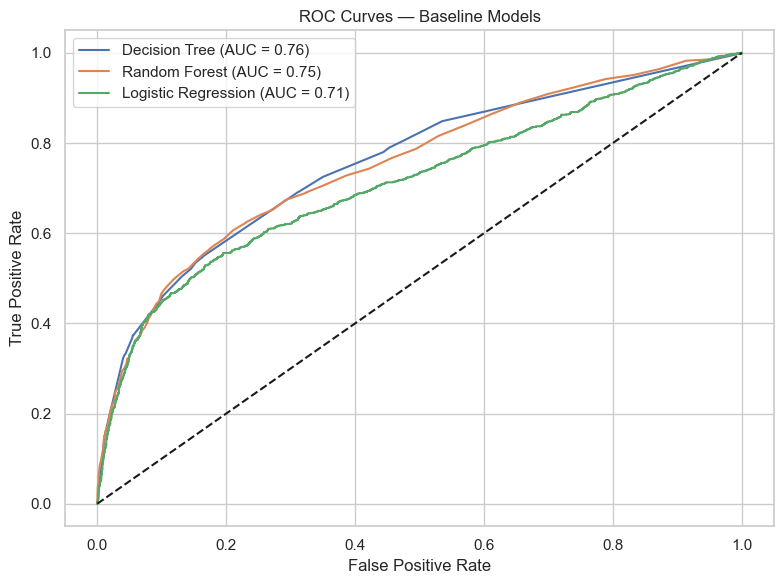

In [18]:
from sklearn.metrics import roc_curve, auc

# Create figure for plotting all ROC curves on the same axes
fig, ax = plt.subplots(figsize=(8, 6))

# Define models with their corresponding test sets
# Logistic Regression uses scaled features to match training conditions
models = {
    'Decision Tree': (dt_base, X_test_b),
    'Random Forest': (rf_base, X_test_b),
    'Logistic Regression': (lr_base, X_test_scaled)
}

for name, (model, X) in models.items():

    # Get predicted probabilities for the default class (class 1)
    # predict_proba()[:,1] returns P(default) for each client
    y_prob = model.predict_proba(X)[:, 1]

    # Compute FPR and TPR across all classification thresholds
    fpr, tpr, _ = roc_curve(y_test_b, y_prob)

    # Compute AUC score — higher means better ranking of defaults vs non-defaults
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for this model
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot the random baseline (AUC = 0.5) for reference
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Baseline Models')
ax.legend()
plt.tight_layout()
# Save figure for use in the report
plt.savefig('fig_roc.png', dpi=150)
plt.show()

## 19. Feature Engineering — Aggregate Bill and Payment Features

Derives three aggregate features from the monthly billing and payment columns:

- `avg_bill_amt`: mean monthly bill amount across the six billing periods.
- `avg_pay_amt`: mean monthly payment amount across the six payment periods.
- `payment_ratio`: ratio of average payment to average bill, clipped to `[0, 2]` to prevent distortion from near-zero denominators.

In [19]:
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

df['avg_bill_amt'] = df[bill_cols].mean(axis=1)
df['avg_pay_amt'] = df[pay_amt_cols].mean(axis=1)

# Creating the Payment Ratio
df['payment_ratio'] = (df['avg_pay_amt'] / (df['avg_bill_amt'].clip(lower=1))).clip(0, 2)

## 20. Payment Ratio Distribution by Default Status

Visualizes the kernel density estimate of `payment_ratio` stratified by `Is_Default`. A lower payment ratio in the default group would confirm that partial or non-payment behavior is a meaningful discriminative signal.

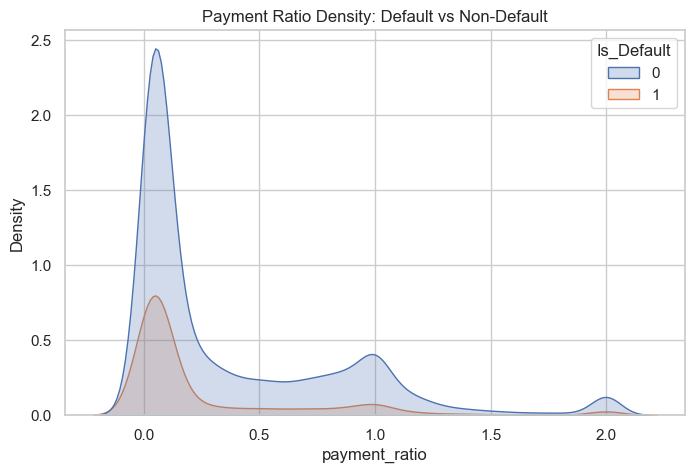

In [20]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='payment_ratio', hue='Is_Default', fill=True)
plt.title('Payment Ratio Density: Default vs Non-Default')
plt.show()

## 21. Feature Engineering — Behavioral, Financial, and Demographic Features

Constructs an extended feature set organized into five groups:

1. **Payment Delay Metrics** — average delay, delay trend, months in delay, and maximum delay.
2. **Financial Gap & Debt Trend** — gap between average bill and payment, bill trend over time.
3. **Credit Utilization** — ratio of average bill to credit limit, limit normalized by age.
4. **Demographic Binning** — age groups and quantile-based limit categories to capture non-linear effects.
5. **Payment Volatility** — standard deviation of monthly payment amounts as a consistency indicator.

In [21]:
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
df['avg_payment_delay'] = df[pay_cols].mean(axis=1)
df['payment_delay_trend'] = df['PAY_0'] - df['PAY_6']
df['n_months_delayed'] = (df[pay_cols] > 0).sum(axis=1)
df['max_delay'] = df[pay_cols].max(axis=1)

# 2. Financial Gaps & Debt Trends
df['bill_pay_gap'] = df['avg_bill_amt'] - df['avg_pay_amt']
df['bill_trend'] = df['BILL_AMT1'] - df['BILL_AMT6']

# 3. Limit & Utilization Metrics
# credit_utilization is capped at 1 (100% usage)
df['credit_utilization'] = (df['avg_bill_amt'] / (df['LIMIT_BAL'] + 1)).clip(0, 1)
df['limit_per_age'] = df['LIMIT_BAL'] / df['AGE']

# 4. Demographics & Binning (Non-linear relationship captures)
# Age groups
df['age_group'] = pd.cut(df['AGE'], 
                        bins=[20, 30, 40, 50, 60, 90], 
                        labels=['20s', '30s', '40s', '50s', '60+'])

# Limit categories (Quantile-based binning)
df['limit_category'] = pd.qcut(df['LIMIT_BAL'], q=4, 
                             labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

# 5. Volatility & Consistency
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
df['payment_consistency'] = df[pay_amt_cols].std(axis=1)

print("Feature Engineering completed successfully. New total features:", df.shape[1])

Feature Engineering completed successfully. New total features: 39


## 22. Encoding of Ordinal Categorical Features

Converts the ordinal binned features (`age_group` 
and `limit_category`) into integer codes via label 
encoding, preserving their inherent order. 

Label encoding was chosen over one-hot encoding 
for these two variables because both features are 
**ordinal**, their categories have a meaningful 
sequence. One-hot encoding would 
treat each category as independent and destroy 
this ordering information, which is particularly 
important for tree-based models that rely on 
threshold-based splits. With label encoding, a 
decision tree can learn rules such as 
"limit_category_code >= 2" in a single split, 
whereas one-hot encoding would require multiple 
splits to capture the same pattern.

The original categorical columns (`age_group`, 
`limit_category`) are subsequently dropped to 
avoid redundancy in the final feature matrix.

In [22]:
# 1. Label Encoding for Ordinal Features

df['age_group_code'] = df['age_group'].cat.codes
df['limit_category_code'] = df['limit_category'].cat.codes

# 2. One-Hot Encoding

df.drop(['age_group', 'limit_category'], axis=1, inplace=True)
print(df[['age_group_code', 'limit_category_code']].head())

   age_group_code  limit_category_code
0               0                    0
1               0                    1
2               1                    1
3               1                    0
4               3                    0


## 23. Dimensionality Reduction — Removal of Redundant Columns

Drops highly correlated or informationally redundant columns (`ID`, individual `BILL_AMT` columns, and `PAY_2` through `PAY_6`) that have been superseded by the engineered aggregate features. This produces the final feature matrix `df_final` used for model training.

In [23]:
redundant_cols = [
    'ID',  
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'age_group', 'limit_category'
]

df_final = df.drop(columns=redundant_cols, errors='ignore')

# Report the column count before and after removal
print(f"Previous column count: {df.shape[1]}")
print(f"Updated column count: {df_final.shape[1]}")
print("Redundant columns have been successfully removed.")

Previous column count: 39
Updated column count: 27
Redundant columns have been successfully removed.


## 24. Model Training on Engineered Feature Set

Re-trains the three classifiers (Decision Tree, Random Forest, Logistic Regression) on the engineered feature matrix `df_final`. Results are compared against the baseline to quantify the predictive lift achieved through feature engineering.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Splitting the target and features
X = df_final.drop('Is_Default', axis=1)
y = df_final['Is_Default']

# 2. Train-Test Split (80% Training, 20% Testing)
# 'stratify=y' ensures that the 22% default rate is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Separate scaling for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on training set only
X_test_scaled  = scaler.transform(X_test)        # apply transform to test set


# Identify columns with missing values prior to model fitting
print("Columns containing missing values:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

# 3. Decision Tree Model
# Using class_weight='balanced' to handle the 22% vs 78% imbalance
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)

# 4. Random Forest Model
# Building an ensemble of 100 trees for better generalization
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)


lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

print("--- Models have been trained successfully. ---\n")

# Function to evaluate models
def evaluate_model(model, X_test, y_test, model_name):
    predictions = model.predict(X_test)
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, predictions))
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))
    print("-" * 50)

# Evaluate both models
evaluate_model(dt_model, X_test, y_test, "Decision Tree")
evaluate_model(rf_model, X_test, y_test, "Random Forest")
evaluate_model(lr_model, X_test_scaled, y_test, "Logistic Regression")

Columns containing missing values:
Series([], dtype: int64)
--- Models have been trained successfully. ---

--- Decision Tree Performance ---
Accuracy: 0.7433

Confusion Matrix:
[[3614 1059]
 [ 481  846]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      4673
           1       0.44      0.64      0.52      1327

    accuracy                           0.74      6000
   macro avg       0.66      0.71      0.67      6000
weighted avg       0.79      0.74      0.76      6000

--------------------------------------------------
--- Random Forest Performance ---
Accuracy: 0.8133

Confusion Matrix:
[[4433  240]
 [ 880  447]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.65      0.34      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.67      6000


## 25. ROC Curve - Engineered Feature Models

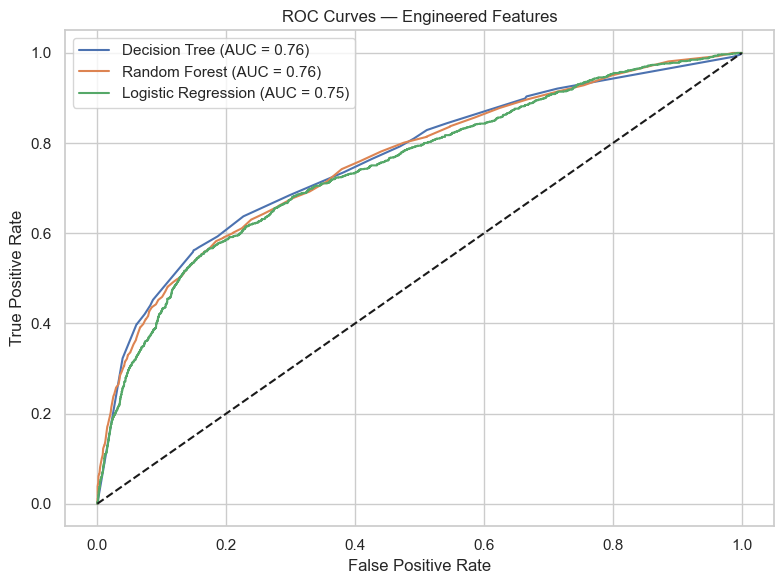

In [25]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

models = {
    'Decision Tree': (dt_model, X_test),
    'Random Forest': (rf_model, X_test),
    'Logistic Regression': (lr_model, X_test_scaled)
}

for name, (model, X) in models.items():
    y_prob = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Engineered Features')
ax.legend()
plt.tight_layout()
plt.savefig('fig_roc.png', dpi=150)
plt.show()

## 26. Feature Importance Visualization

Visualizes the top-10 most influential features for each trained model:

- **Decision Tree & Random Forest**: uses the built-in `feature_importances_` attribute (Gini-based impurity reduction).
- **Logistic Regression**: uses the absolute value of coefficients as a proxy for feature influence, since negative coefficients carry equal predictive weight in the opposite direction.

C:\Users\zeyne\AppData\Local\Temp\ipykernel_31932\3129812073.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


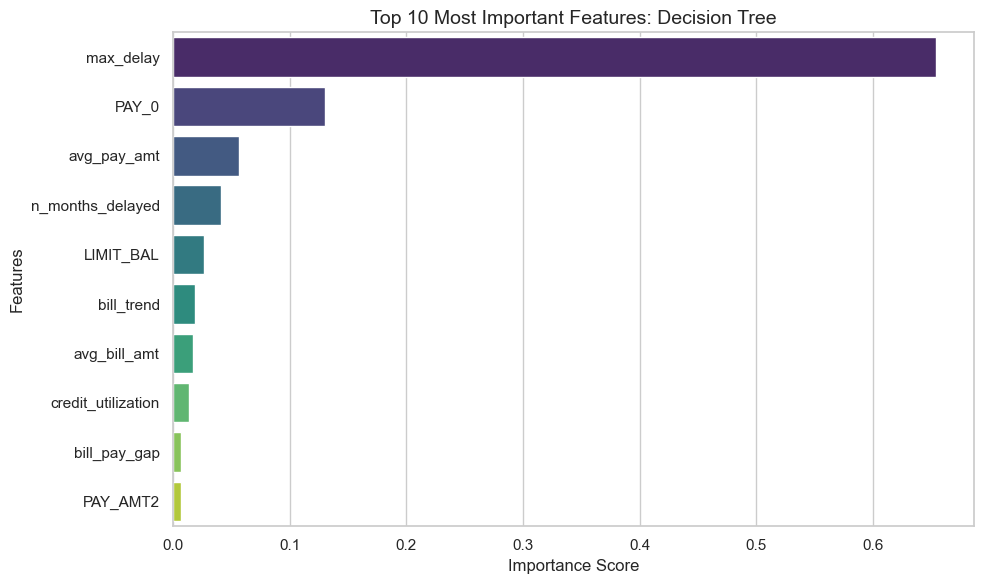

C:\Users\zeyne\AppData\Local\Temp\ipykernel_31932\3129812073.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


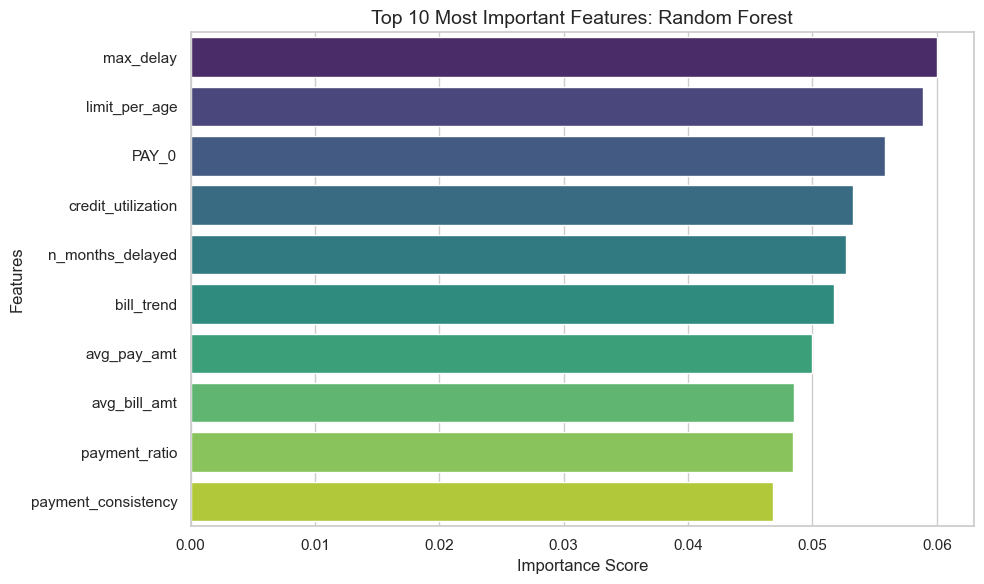

C:\Users\zeyne\AppData\Local\Temp\ipykernel_31932\3129812073.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


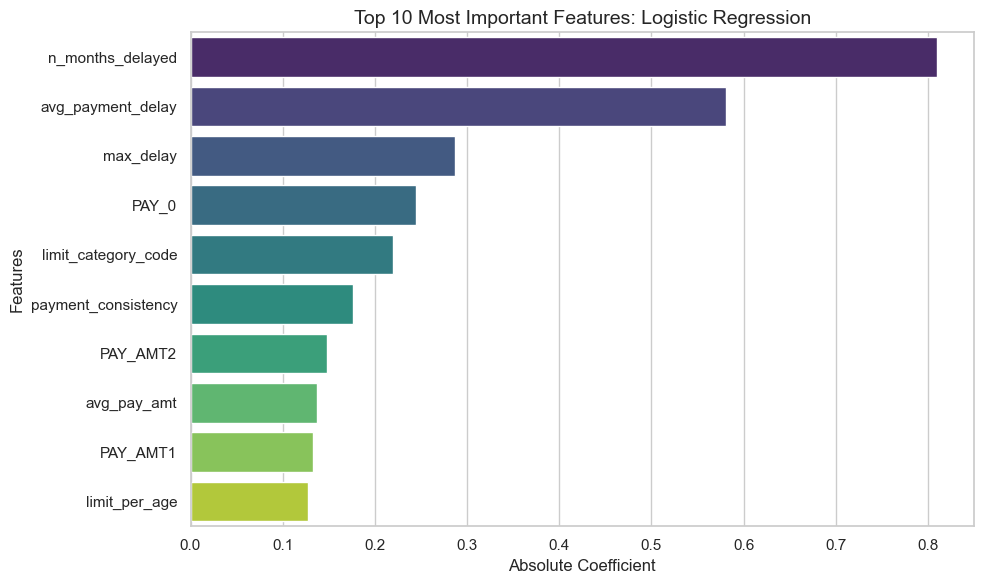

In [26]:
def plot_feature_importance(model, X, model_name, scaler=None):
   
    plt.figure(figsize=(10, 6))

    if hasattr(model, 'feature_importances_'):
        # Decision Tree & Random Forest — Gini-based importance
        importances   = model.feature_importances_
        feature_names = X.columns
        label         = 'Importance Score'

    elif hasattr(model, 'coef_'):
        # Logistic Regression — absolute coefficient value
        # Absolute value is used because negative coefficients are equally informative
        importances   = abs(model.coef_[0])
        feature_names = X.columns  # Column names remain identical to the unscaled set
        label         = 'Absolute Coefficient'

    else:
        print(f'Feature importance cannot be computed for {model_name}.')
        return

    feat_df = (pd.DataFrame({'Feature': feature_names, 'Importance': importances})
               .sort_values('Importance', ascending=False)
               .head(10))

    sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
    plt.title(f'Top 10 Most Important Features: {model_name}', fontsize=14)
    plt.xlabel(label)
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()


# ── Generate importance plots for all three models ────────────────────────
plot_feature_importance(dt_model, X_train,        "Decision Tree")
plot_feature_importance(rf_model, X_train,        "Random Forest")
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
plot_feature_importance(lr_model, X_train_scaled_df, "Logistic Regression")

# NOTE: For lr_model, X_train_scaled is passed but column names are sourced from X_train.
